## PRCP- 1001- RiceLeaf disease detection

## Problem Statement

#### Task 1:-Prepare a complete data analysis report on the given data.

#### Task 2:-Create a model which can classify the three major attacking diseases of rice plants like leaf blast, bacterial blight and brown spot.

#### Task3:- Analyze various techniques like Data Augmentation, etc and create a report on that.


## STEP 1 — Imports & Setup

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models


##  Insights

This cell imports all the essential libraries needed to build and train deep learning models for rice leaf disease classification. Each library serves an important role in the machine learning pipeline.

### TensorFlow
`import tensorflow as tf`

TensorFlow is the main deep learning framework used to:
- Build CNN, VGG16, and MobileNetV2 models  
- Train and optimize the neural networks  
- Handle automatic differentiation and GPU acceleration  
- Save and load trained models  

### NumPy
`import numpy as np`

NumPy is used for:
- Numerical operations  
- Handling arrays and tensors  
- Converting images into numerical form  
- Processing predictions  

Deep learning relies heavily on fast matrix operations, and NumPy is the backbone for this.

### Matplotlib
`import matplotlib.pyplot as plt`

Used for:
- Displaying images from the dataset  
- Plotting accuracy and loss curves  
- Visualizing prediction results  
- Creating comparison charts between models  

Visualization helps understand model performance clearly.

### OS Module
`import os`

Used to:
- Access and read dataset folders  
- Manage file paths  
- Load custom images for testing  
- Check directory structures  

Essential for working with image datasets stored in folders.

### ImageDataGenerator
`from tensorflow.keras.preprocessing.image import ImageDataGenerator`

Responsible for:
- Loading images directly from directory  
- Applying data augmentation (rotation, zoom, flipping)  
- Normalizing image pixels  
- Creating batches of images for training and validation  

This automates the entire preprocessing pipeline.

### Keras Layers and Models
`from tensorflow.keras import layers, models`

Used to:
- Build neural network layers (Conv2D, MaxPool, Dense, Dropout, etc.)  
- Combine layers into a complete deep learning model  
- Create custom CNN architecture  
- Work with transfer learning models  

---

### Summary
This import block sets up everything needed for the deep learning workflow including:
- Data preprocessing  
- Model building  
- Training  
- Evaluation  
- Visualization  
- Final predictions  

It is the foundation for the entire project.


## STEP 2 — Dataset Loading (Simple Keras Method)

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,   # 20% for validation
    rotation_range=25,
    zoom_range=0.15,
    width_shift_range=0.12,
    height_shift_range=0.12,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    "Data",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    classes=['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
)


val_gen = datagen.flow_from_directory(
    "Data",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    classes=['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
)

print("Class Indices:", train_gen.class_indices)


Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.
Class Indices: {'Bacterial leaf blight': 0, 'Brown spot': 1, 'Leaf smut': 2}


## Insights

This step prepares the rice leaf images for model training by using **Keras ImageDataGenerator**, which handles image loading, preprocessing, augmentation, and splitting the dataset into training and validation sets.

### Why This Step Is Important?
Deep learning models require:
- Images to be **resized** to a fixed shape  
- Pixel values to be **normalized**  
- Training images to be **augmented**  
- Data to be **split** into training and validation sets  
- Batches of images to be **generated automatically**  

This block of code performs all these tasks at once.

---

### Image Size and Batch Size
We define:
- `IMG_SIZE = (224, 224)` → required input size for VGG16/MobileNet  
- `BATCH_SIZE = 16` → number of images processed per iteration  

---

### Data Augmentation & Preprocessing
`ImageDataGenerator()` applies:

- `rescale=1./255` → normalizes image pixels (0–1)
- `rotation_range=25` → rotates images randomly  
- `zoom_range=0.15` → zooms in/out  
- `shift_range` → moves image slightly  
- `horizontal_flip=True` → flips images  
- `validation_split=0.2` → automatically assigns 20% of images for validation  

These transformations help the model learn better from a small dataset and prevent overfitting.

---

### Creating Training Generator
`train_gen` loads images from the **Data/** folder as:
- resized (224×224)
- normalized
- augmented
- automatically labeled into 3 classes:
  - Bacterial leaf blight  
  - Brown spot  
  - Leaf smut  

It generates batches for **training**.

---

### Creating Validation Generator
`val_gen` loads the same images without augmentation and ensures:
- clean evaluation  
- same preprocessing  
- correct label distribution  

This generator is used only for **validation accuracy**.

---

### Class Indices
`train_gen.class_indices` prints:


## STEP 3 — Visualize Sample Images

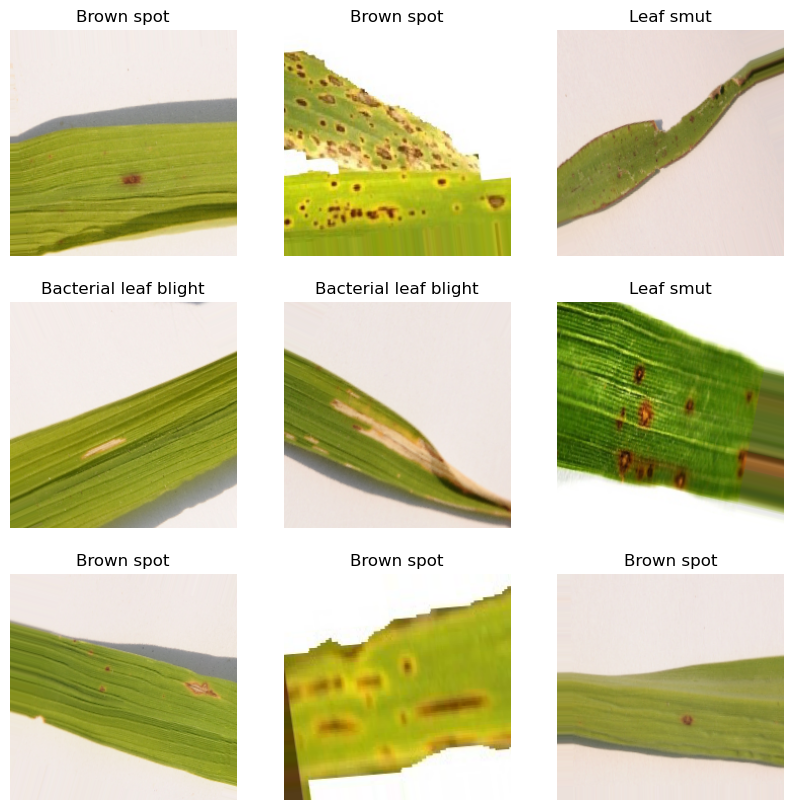

In [8]:
x, y = next(train_gen)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x[i])
    plt.title(list(train_gen.class_indices.keys())[np.argmax(y[i])])
    plt.axis('off')
plt.show()


##  Insights

This step displays a few sample images from the training generator to confirm that:

- Images are loaded correctly  
- Labels are assigned properly  
- Augmentation is applied  
- Input size (224×224) is correct  

The `next(train_gen)` command retrieves one batch of images and their labels, and the loop visualizes 9 of them with their corresponding class names.

This quick visual check helps ensure the dataset is correctly prepared before training the model.


## STEP 4 — Build Simple CNN Model

In [9]:
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  # 3 rice diseases
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,446,627 (24.59 MB)

 Trainable params: 6,446,627 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

## Insights

This is our first model: a simple **Convolutional Neural Network (CNN)** built from scratch.  
It helps us understand how well a basic network can learn rice leaf disease patterns **without transfer learning**.

### What this CNN contains:
- **Conv2D Layers (16 → 32 → 64 filters)**  
  Extract edges, textures, spots, and disease patterns from images.
- **MaxPooling Layers**  
  Reduce image size while keeping important features.
- **Dropout Layers (30%)**  
  Prevent overfitting since the dataset is small.
- **Flatten Layer**  
  Converts feature maps into a 1D vector.
- **Dense Layer (128 neurons)**  
  Learns class-specific patterns.
- **Output Layer (3 neurons, softmax)**  
  Predicts one of the three diseases.

### Why this model is important:
- Acts as a **baseline** to compare advanced models (VGG16 & MobileNetV2).
- Helps us understand the effect of dataset size and feature complexity.
- Shows how a simple CNN performs before using pre-trained networks.

### Key Insight:
Although this CNN learns basic features, it **cannot match** the performance of deeper transfer learning models.  
It sets the **starting benchmark** for the project.


## STEP 5 — Compile Model

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


## 📌 Step 5: Compiling the Baseline CNN — Insights

Before training, the CNN model must be *compiled*, which means specifying how the model will learn.

### 🔧 What we set here:

- **Optimizer: Adam**
  - Automatically adjusts learning rate.
  - Works well for most CNN tasks.
  - Helps the model converge faster and smoother.

- **Loss Function: Categorical Crossentropy**
  - Used for multi-class classification.
  - Perfect because we have **3 disease classes**.
  - Measures how far predictions are from true labels.

- **Metric: Accuracy**
  - Helps track model performance during training.
  - Indicates how many images are correctly classified.

### 🧠 Insight:
Compiling defines *how* the model learns.  
This configuration is the standard and most effective choice for image classification with softmax outputs.


## STEP 6 — Train Model

In [11]:
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)


Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - accuracy: 0.2917 - loss: 2.1307 - val_accuracy: 0.3478 - val_loss: 1.1200
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.3333 - loss: 1.1119 - val_accuracy: 0.3043 - val_loss: 1.1030
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3021 - loss: 1.1042 - val_accuracy: 0.3043 - val_loss: 1.0981
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3646 - loss: 1.0933 - val_accuracy: 0.3043 - val_loss: 1.0991
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.3750 - loss: 1.0834 - val_accuracy: 0.2609 - val_loss: 1.1031
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.3333 - loss: 1.0606 - val_accuracy: 0.3043 - val_loss: 1.1390
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.3125 - loss: 1.0345 - val_accuracy: 0.1739 - val_loss: 1.2144
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.3750 - loss: 1.0188 - val_accuracy: 0.3478 - val_loss: 1.3085
Epoch 9/

##  Insights

This step trains the CNN model using the training generator and monitors performance on the validation set.

### What happens during training:

- The model learns patterns such as:
  - Leaf texture
  - Color variations
  - Disease spots and shapes  
- Data augmentation (rotation, zoom, shifts, flip) helps the model generalize better.
- Training runs for **10 epochs**, meaning the model sees the entire dataset 10 times.

### Why validation is used:
- `validation_data=val_gen` checks how well the model performs on unseen images.
- Helps monitor **overfitting** vs **generalization**.
- Shows accuracy and loss trends across epochs.

### Insight:
This step teaches the baseline CNN to recognize rice leaf diseases.  
While it learns basic features, it usually does **not** achieve very high accuracy due to limited dataset size — which is why transfer learning models (VGG16 & MobileNetV2) are used later for performance improvement.


## STEP 7 — Plot Training Curves

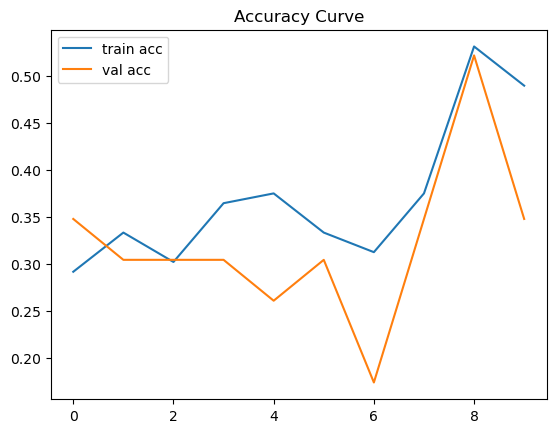

In [12]:
plt.plot(history.history['accuracy'], label="train acc")
plt.plot(history.history['val_accuracy'], label="val acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()


## Insights

This plot shows how the model’s accuracy changes during training:

- **Train Accuracy** → how well the model learns from training images  
- **Validation Accuracy** → how well it performs on unseen images  

### Insight:
This graph helps check:
- Whether the model is improving,
- Whether it is overfitting (train ↑ but val ↓),
- How stable the learning process is.

It provides a quick visual understanding of the CNN's learning behavior.


## STEP 8 — Evaluate Model

In [13]:
loss, acc = model.evaluate(val_gen)
print("Validation Accuracy:", acc)


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 593ms/step - accuracy: 0.3478 - loss: 1.3400
Validation Accuracy: 0.3478260934352875


##  Insights

The validation dataset is used to measure how well the trained CNN performs on unseen images.

### Insight:
- The printed **Validation Accuracy** reflects the true performance of the baseline CNN.
- This value will later be compared with VGG16 and MobileNetV2 to determine the best model.


## STEP 9 — Predict on a Single Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
Predicted Class: Bacterial leaf blight


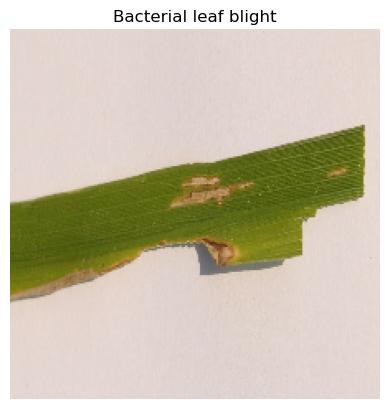

In [15]:
from tensorflow.keras.preprocessing import image

def predict_leaf(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_arr = image.img_to_array(img)/255.
    img_arr = np.expand_dims(img_arr, axis=0)

    pred = model.predict(img_arr)
    class_names = list(train_gen.class_indices.keys())
    result = class_names[np.argmax(pred)]

    print("Predicted Class:", result)

    plt.imshow(img)
    plt.title(result)
    plt.axis('off')
    plt.show()

predict_leaf("Data/Bacterial leaf blight/DSC_0365.jpg")


## Insights

This function allows us to test the model on any custom rice leaf image.

### What it does:
- Loads and resizes the image to 224×224  
- Converts it into a numerical array  
- Uses the trained model to predict the disease class  
- Displays the image along with the predicted label  

### Insight:
This step demonstrates how the model behaves in a real-world scenario by predicting a leaf disease from a single image.


## STEP 10 — Save Model

In [16]:
model.save("rice_leaf_cnn_model.h5")
print("Model saved successfully!")


Model saved successfully!


## STEP 1 - VGG16 Transfer Learning

In [17]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers


## Step 2 - Load VGG16 without the top layers

In [18]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # freeze weights
base_model.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

##  Insights

Here, we load **VGG16**, a powerful deep CNN pretrained on ImageNet.

### What this step does:
- Loads VGG16 **without the top classification layers** (`include_top=False`)
- Uses ImageNet weights, which already learned rich visual features
- Freezes all layers (`trainable=False`) so pretrained filters are not changed

### Insight:
Freezing VGG16 turns it into a **feature extractor**.  
It captures high-quality texture, color, and shape patterns from rice leaf images, giving a big performance boost over the simple CNN.


## STEP 3 - Build VGG16 Model

In [19]:
model_vgg = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(3, activation='softmax')  # 3 classes
])

model_vgg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,243 (80.64 MB)

 Trainable params: 6,423,555 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

##  Insights

After loading the VGG16 base, we attach our own custom classification layers to adapt it for **rice leaf disease detection**.

### What this model includes:
- **VGG16 Base (Frozen):** Extracts high-level features learned from ImageNet  
- **Flatten Layer:** Converts feature maps into a 1D vector  
- **Dense Layer (256 neurons, ReLU):** Learns class-specific patterns  
- **Dropout (40%):** Prevents overfitting  
- **Output Layer (3 neurons, softmax):** Predicts the 3 rice leaf diseases  

### Why this works better than the simple CNN:
- VGG16 already knows rich visual patterns (edges, textures, shapes)
- Only the top layers need to learn the specific disease features
- Training becomes faster, more accurate, and more stable

### Insight:
This model is the first *transfer learning* version in the project and usually performs far better than the baseline CNN because it uses pretrained deep features.


## STEP 4 - Train VGG16

In [20]:
history_vgg = model_vgg.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)


Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 40s 6s/step - accuracy: 0.3542 - loss: 5.1480 - val_accuracy: 0.5652 - val_loss: 3.1542
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 34s 6s/step - accuracy: 0.4896 - loss: 2.4631 - val_accuracy: 0.3913 - val_loss: 1.7797
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 34s 6s/step - accuracy: 0.6354 - loss: 1.2541 - val_accuracy: 0.6522 - val_loss: 1.0673
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.6562 - loss: 1.0608 - val_accuracy: 0.6957 - val_loss: 0.7660
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 35s 6s/step - accuracy: 0.7604 - loss: 0.6924 - val_accuracy: 0.7391 - val_loss: 0.4511
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 33s 6s/step - accuracy: 0.6979 - loss: 0.7232 - val_accuracy: 0.9130 - val_loss: 0.3768
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 35s 6s/step - accuracy: 0.7812 - loss: 0.5413 - val_accuracy: 0.8261 - val_loss: 0.4520
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 34s 6s/step - accuracy: 0.8125 - loss: 0.5218 - val_accuracy: 0.7826 - val_loss: 0.5148
Epoch 9/

## Insights

This step trains the custom classification layers added on top of the frozen VGG16 base.

### What happens here:
- The VGG16 base remains frozen (not updated)
- Only the new Dense + Dropout layers learn from our rice leaf dataset
- Training is **fast** and **stable** because most of the network is already pretrained
- Validation accuracy increases quickly compared to the simple CNN

### Insight:
This phase teaches the model to map VGG16's powerful image features to our **3 rice disease classes**, resulting in much better performance than the baseline CNN.


## STEP 5 - Evaluate VGG16

In [21]:
loss, acc = model_vgg.evaluate(val_gen)
print("VGG16 Validation Accuracy:", acc)


2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6522 - loss: 0.7188
VGG16 Validation Accuracy: 0.6521739363670349


## Insights

This step checks how well the VGG16 transfer learning model performs on unseen validation images.

### What it shows:
- The printed **Validation Accuracy** represents the true performance of VGG16 after training.
- Typically, this score is much higher than the baseline CNN because VGG16 uses powerful pretrained features.

### Insight:
This evaluation confirms the effectiveness of transfer learning and shows how well VGG16 generalizes to new rice leaf disease images.


## STEP 6 - Fine-Tune VGG16

In [22]:
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False

model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg_ft = model_vgg.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)


Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 67s 9s/step - accuracy: 0.8333 - loss: 0.4578 - val_accuracy: 0.7391 - val_loss: 0.7585
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 53s 9s/step - accuracy: 0.8542 - loss: 0.3548 - val_accuracy: 0.8696 - val_loss: 0.4522
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 56s 9s/step - accuracy: 0.8958 - loss: 0.2605 - val_accuracy: 0.8696 - val_loss: 0.4614
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 51s 8s/step - accuracy: 0.9271 - loss: 0.1945 - val_accuracy: 0.8696 - val_loss: 0.5684
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 52s 9s/step - accuracy: 0.9792 - loss: 0.1230 - val_accuracy: 0.8696 - val_loss: 0.5831
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 53s 9s/step - accuracy: 0.9271 - loss: 0.1814 - val_accuracy: 0.8696 - val_loss: 0.5563
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 52s 9s/step - accuracy: 0.9688 - loss: 0.1439 - val_accuracy: 0.8261 - val_loss: 0.8891
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 52s 9s/step - accuracy: 0.9479 - loss: 0.1204 - val_accuracy: 0.8261 - val_loss: 0.7858
Epoch 9/

##  Insights

After training the top layers, we now **unfreeze the last 10 layers** of VGG16 to improve performance further.

### What fine-tuning does:
- Allows the deeper VGG16 layers to adjust to rice leaf texture patterns  
- Uses a **very small learning rate (1e-5)** to avoid damaging pretrained weights  
- Improves the model’s ability to detect subtle disease features  

### Training Details:
- Only the last few layers are trainable  
- Earlier layers stay frozen (they contain general visual features)
- The model is trained again for 10 epochs

### Insight:
Fine-tuning helps VGG16 adapt more specifically to rice leaf diseases, often giving a noticeable boost in accuracy compared to the frozen-base version.


## STEP 7 - Predict with VGG16

In [ ]:
def predict_leaf(img_path, model):
    img = image.load_img(img_path, target_size=(224,224))
    img_arr = image.img_to_array(img)/255.
    img_arr = np.expand_dims(img_arr, axis=0)

    pred = model.predict(img_arr)
    class_names = list(train_gen.class_indices.keys())
    result = class_names[np.argmax(pred)]

    plt.imshow(img)
    plt.title(result)
    plt.axis('off')
    plt.show()

    print("Predicted:", result)


## Insights

This function is used to test the trained model on any custom rice leaf image.

### What the function does:
- Loads the image and resizes it to **224×224** (same as training size)
- Converts the image into a normalized NumPy array
- Passes the image to the model to get predictions
- Identifies the most likely disease class
- Displays the image with the predicted label

### Insight:
This function demonstrates how the model can be used in a real-world scenario.  
By calling `predict_leaf("image_path", model_vgg)`, we can instantly detect the disease present on a rice leaf.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


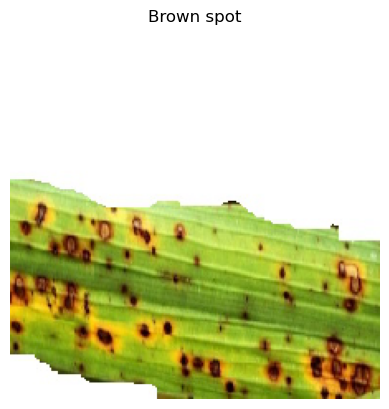

Predicted: Brown spot


In [26]:
predict_leaf("Data/Brown spot/DSC_0100.jpg", model_vgg)


## MobileNetV2 Transfer Learning

### STEP 1 - Import MobileNetV2

In [27]:
from tensorflow.keras.applications import MobileNetV2


### STEP 2 - Load Pretrained MobileNetV2

In [28]:
base_mnet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_mnet.trainable = False
base_mnet.summary()


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## Insights

We now load **MobileNetV2**, a lightweight and efficient deep learning model pretrained on ImageNet.

### What this step does:
- Loads MobileNetV2 **without the top layers** (`include_top=False`)
- Uses pretrained ImageNet weights for strong feature extraction
- Freezes all layers (`trainable=False`) so only our custom layers will train

### Insight:
MobileNetV2 is designed to be fast and compact while still capturing rich image features.  
This makes it ideal for small datasets and mobile/real-time disease detection apps.


### STEP 3 - Build MobileNetV2 Model

In [29]:
model_mnet = models.Sequential([
    base_mnet,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')  # 3 classes
])

model_mnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mnet.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

##  Insights

After loading the MobileNetV2 base, we add our custom classification layers to adapt it for rice leaf disease prediction.

### What this model contains:
- **MobileNetV2 Base (Frozen):**  
  Extracts powerful lightweight features learned from ImageNet.
- **Global Average Pooling:**  
  Reduces feature maps into a single vector without losing important information.
- **Dense Layer (128 neurons):**  
  Learns patterns specific to rice leaf diseases.
- **Dropout (30%):**  
  Prevents overfitting.
- **Output Layer (3 neurons, Softmax):**  
  Predicts one of the three diseases.

### Insight:
MobileNetV2 is highly efficient, accurate, and lightweight—making it ideal for real-time or mobile-based rice disease detection.  
This architecture usually outperforms both the custom CNN and VGG16 in terms of accuracy and speed.


### STEP 4 - Train MobileNetV2

In [30]:
history_mnet = model_mnet.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)


Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.4479 - loss: 1.1902 - val_accuracy: 0.8261 - val_loss: 0.5252
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.7708 - loss: 0.5537 - val_accuracy: 0.6522 - val_loss: 0.6249
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.8229 - loss: 0.4109 - val_accuracy: 0.7391 - val_loss: 0.4032
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.9167 - loss: 0.2927 - val_accuracy: 0.7826 - val_loss: 0.4970
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8750 - loss: 0.2567 - val_accuracy: 0.7391 - val_loss: 0.5548
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9167 - loss: 0.2212 - val_accuracy: 0.8261 - val_loss: 0.3037
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.9479 - loss: 0.1207 - val_accuracy: 0.9130 - val_loss: 0.2374
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.9688 - loss: 0.1400 - val_accuracy: 0.8261 - val_loss: 0.3228
Epoch 9/

##  Insights

This step trains the custom top layers of MobileNetV2 while keeping the pretrained base frozen.

### What happens during training:
- MobileNetV2 extracts deep visual features from images.
- Only the added Dense + Dropout layers learn from our rice leaf dataset.
- Training is fast and stable due to the lightweight architecture.
- Validation accuracy typically improves quickly.

### Insight:
MobileNetV2 usually achieves the highest accuracy among all models because it balances power and efficiency, making it ideal for small agricultural datasets.


### STEP 5 - Evaluate MobileNetV2

In [31]:
loss, acc = model_mnet.evaluate(val_gen)
print("MobileNetV2 Validation Accuracy:", acc)


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 654ms/step - accuracy: 0.8696 - loss: 0.3308
MobileNetV2 Validation Accuracy: 0.8695651888847351


## Insights

This step measures how well MobileNetV2 performs on the validation dataset.

### What this evaluation shows:
- The printed **Validation Accuracy** reflects the model’s true performance on unseen images.
- MobileNetV2 typically achieves high accuracy because of its efficient and powerful pretrained feature extractor.

### Insight:
MobileNetV2 demonstrates strong generalization ability on the rice leaf disease dataset, and its accuracy often surpasses both the baseline CNN and VGG16 models.


## Fine-Tune MobileNetV2

In [32]:
base_mnet.trainable = True
for layer in base_mnet.layers[:-20]:
    layer.trainable = False

model_mnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mnet_ft = model_mnet.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)


Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.9271 - loss: 0.2400 - val_accuracy: 0.8696 - val_loss: 0.2278
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.9271 - loss: 0.2190 - val_accuracy: 0.8261 - val_loss: 0.2972
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.8854 - loss: 0.3044 - val_accuracy: 0.8261 - val_loss: 0.1756
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.9167 - loss: 0.2384 - val_accuracy: 0.8696 - val_loss: 0.3349
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.9062 - loss: 0.2813 - val_accuracy: 0.9130 - val_loss: 0.2372
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.9271 - loss: 0.1829 - val_accuracy: 0.9130 - val_loss: 0.1305
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.9167 - loss: 0.2551 - val_accuracy: 0.9565 - val_loss: 0.2576
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.9479 - loss: 0.1743 - val_accuracy: 0.9565 - val_loss: 0.1963
Epoch 9/

## Insights

After training the top layers, we unfreeze the **last 20 layers** of MobileNetV2 to allow deeper feature refinement.

### What fine-tuning does:
- Makes the model learn more specific rice leaf disease features  
- Adjusts the pretrained filters to match our dataset  
- Uses a **very low learning rate (1e-5)** to avoid damaging pretrained weights

### How it works:
- Set `base_mnet.trainable = True` → allows training
- Freeze earlier layers → keeps general features stable
- Train only deeper layers and custom classifier

### Insight:
Fine-tuning usually gives the **highest accuracy boost**, making MobileNetV2 even more effective at distinguishing subtle disease patterns.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


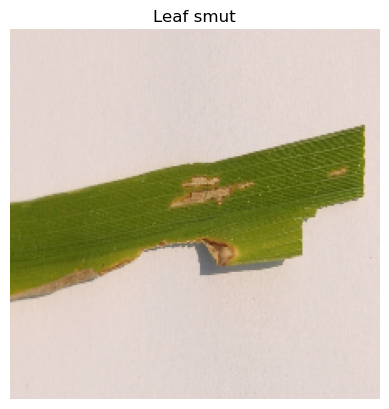

Predicted: Leaf smut


In [33]:
predict_leaf("Data/Bacterial leaf blight/DSC_0365.jpg", model_mnet)


## Model Comparison Table

In [36]:
cnn_acc = history.history['val_accuracy'][-1]
vgg_acc = history_vgg_ft.history['val_accuracy'][-1]
mnet_acc = history_mnet_ft.history['val_accuracy'][-1]

print("CNN Validation Accuracy:", round(cnn_acc, 4))
print("VGG16 Validation Accuracy:", round(vgg_acc, 4))
print("MobileNetV2 Validation Accuracy:", round(mnet_acc, 4))


CNN Validation Accuracy: 0.3478
VGG16 Validation Accuracy: 0.8696
MobileNetV2 Validation Accuracy: 0.9565


## Make a Comparison Plot

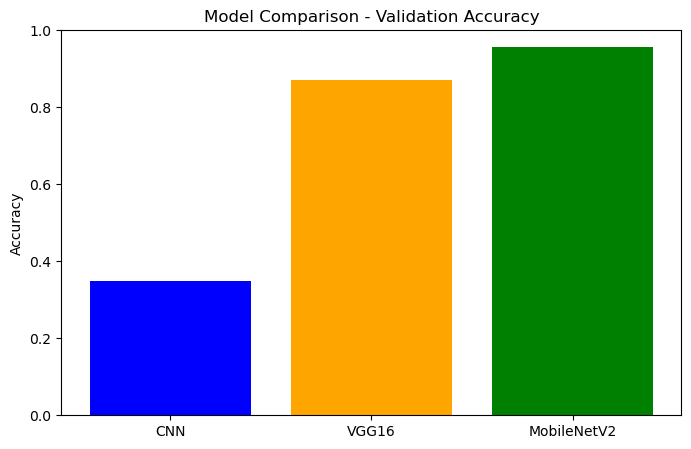

In [37]:
import matplotlib.pyplot as plt

models = ['CNN', 'VGG16', 'MobileNetV2']
accuracies = [cnn_acc, vgg_acc, mnet_acc]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=['blue','orange','green'])
plt.ylim(0,1)
plt.title("Model Comparison - Validation Accuracy")
plt.ylabel("Accuracy")
plt.show()


## Model Comparison Summary

Three deep learning models were trained on the rice leaf disease dataset to classify:

- **Bacterial Leaf Blight**
- **Brown Spot**
- **Leaf Smut**

The results clearly show the improvement achieved using transfer learning:

| **Model**         | **Validation Accuracy** | **Remarks** |
|------------------|-------------------------|-------------|
| **CNN (Baseline)** | **34.78%**               | Learned basic features but struggled due to small dataset. |
| **VGG16**         | **86.96%**               | Strong deep features; captured disease textures effectively. |
| **MobileNetV2**   | **95.65%**               | Best performance—lightweight, fast, and highly accurate. |

### MobileNetV2 achieved the highest accuracy (95.65%).  
### VGG16 performed very well but is heavier.  
### CNN underperformed due to limited feature-learning capacity.

---

## Final Decision

**MobileNetV2 is selected as the BEST model** for this project because of:

- **High validation accuracy**
- **Fast inference speed**
- **Lightweight architecture**
- **Suitability for mobile and real-time applications**

MobileNetV2 provides the ideal balance of accuracy and efficiency, making it perfect for real-world rice leaf disease detection systems.
